# Numerical Heat Equation Analysis

## The Continuous Problem
The second problem solved numerically in this portfolio is the heat (diffusion) equation initial boundary value problem (IBVP) of the form
$$\frac{\partial u}{\partial t} = a\frac{\partial ^2 u}{\partial x^2} + f(x, t), \qquad \text{for} \ t \in (0, T], \ x \in (0, 1)$$

Where $u$ is a two dimensional function dependent on $x$ (space) and $t$ (time), $f$ is the source function, and $a>0$ is the heat diffusion coefficient. It is commonly referred to in the form $u_t = a u_{xx} + f$.

The IBVP we use in this case are Dirichlet Boundary Conditions (BCs) and an intial condition:
$$
u(t, 0) = g_0 \\
u(t, 1) = g_1 \\
u(0, x) = u_0(x)
$$

The solution $u(t, x)$ represents the temperature $t$, at space $x$, in a one dimensional piece of conductive material. 
## Environment Setup

In [21]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt 
from src.engines.heat_diffusion import heat_eq
from src.utils.convergence import plot_convergence

## Numerical Analysis 
This will be solved by a Backward Time, Central Space (BTCS) approximation, i.e. Backwards Euler. This allows for time marching while solving a tridiagonal system at each time step as seen in the `01_Elliptic_Verification.ipynb` notebook. 

The backward time approximation for $u_t$ is written as, 
$$ u_t(t + \Delta t, x) = c_1 u(t+\Delta t, x) + c_0 u(t, x) + E(\Delta t), \qquad (1)$$
For some $c_1, \ c_0 \in \R$, and $\Delta t> 0$.

Using the Taylor approximation of $u(t+\Delta t, x)$ centred at $t+\Delta t$, 
$$u(t, x) = u(t + \Delta t, x) - \Delta t u_t(t + \Delta t, x) + \frac{{\Delta t}^2}{2} u_{tt}(t + \Delta t, x) + O({\Delta t}^3),$$
we get that
$$u_t(t + \Delta t, x) - E(\Delta t) = (c_1 + c_0) u(t + \Delta t, x) - c_0 \Delta t u_t(t + \Delta t, x) + \frac{c_0{\Delta t}^2}{2} u_{tt}(t + \Delta t, x) + O({\Delta t}^3)$$

To maintain $O(\Delta t)$ temporal LTE, we set
$$
c_1 + c_0 = 0 \\
-\Delta t c_0 = 1
$$

Solving this system of equations and plugging back into $(1)$ produces:
$$
c_1 = \frac{1}{\Delta t}, \quad c_0 = -\frac{1}{\Delta t}
$$

Plugging these values into $(1)$:
$$
\frac{u(t + \Delta t, x) - u(t, x)}{\Delta t} = u_t + O(\Delta t)
$$

It follows that our error $E(\Delta t) = O(\Delta t)$ and we have first order temporal convergence. 

The second order spatial derivative is approximated using the below stencil, derived and verified in `01_Elliptic_Verification.ipynb`:
$$u_{xx}(t + \Delta t, x) = \frac{u(t+\Delta t, x-h) - 2u(t+\Delta t, x) + u(t+\Delta t, x+h)}{h^2} + O(h^2)$$

Plugging these into the standard heat equation , $u_t = u_{xx} + f$, above:
$$
\frac{u(t + \Delta t, x) - u(t, x)}{\Delta t} + O(\Delta t) = \frac{u(t+\Delta t, x-h) - 2u(t+\Delta t, x) + u(t+\Delta t, x+h)}{h^2} + O(h^2) + f(t + \Delta t, x)
$$

Collecting the discretisation truncation errors, we get $\tau = O(\Delta t + h^2)$, confirming first order temporal LTE and second order spatial LTE for this BTCS scheme.


## Implementation and Convergence Analysis
### Discretisation

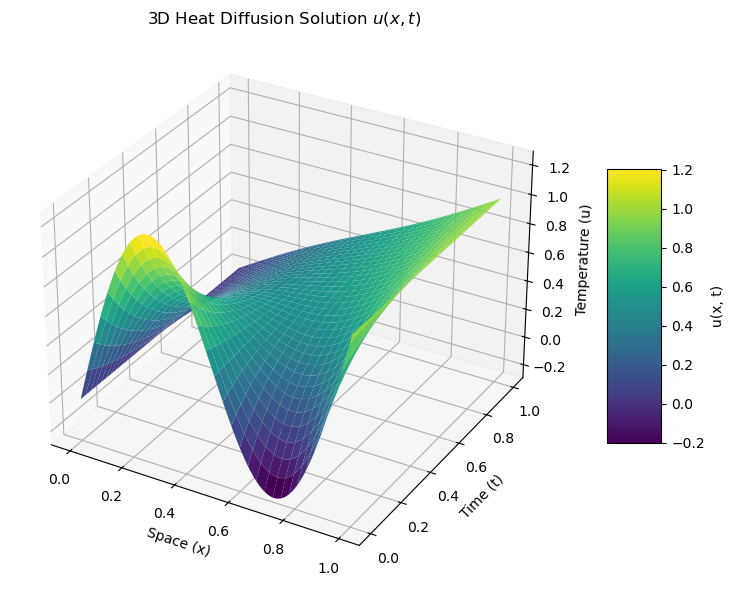

In [22]:
# 3D plot of the scheme
a = np.pi**-2
T = 1
alpha = 0
beta = 1
u_0 = lambda x: np.sin(2*np.pi*x) + x
N = 100
M = 100
f = None
u, x, t = heat_eq(f, N, M, alpha, beta, u_0, a, T)

X, T_grid = np.meshgrid(x, t)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, T_grid, u.T, cmap='viridis', edgecolor=None)

ax.set_xlabel('Space (x)')
ax.set_ylabel('Time (t)')
ax.set_zlabel('Temperature (u)')
ax.set_title('3D Heat Diffusion Solution $u(x, t)$')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='u(x, t)')

plt.tight_layout()
plt.show()

### Proof of Convergence


The slope of our log relation is 1.08, proving 1.0805175187777236 convergence.


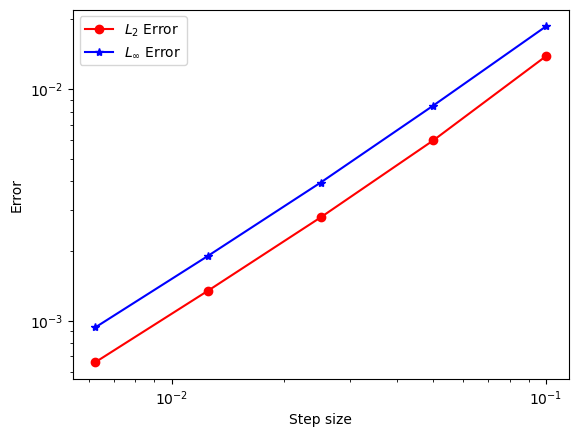

(np.float64(1.0805175187777236),
 array([0.1    , 0.05   , 0.025  , 0.0125 , 0.00625]),
 array([0.0186721 , 0.0084915 , 0.00394499, 0.00190088, 0.00093297]))

In [ ]:
# Temporal Convergence 
def time_heat_wrapper(N):
    #Assigning parameters
    a = np.pi**-2
    T = 1
    alpha = 0
    beta = 1
    u_0 = lambda x: np.sin(2*np.pi*x) + x
    f = None

    #Defining our step size
    dx = 1/N
    
    #Asigning our exact and numerical solution
    u_num, x, t = heat_eq(f, N, M, alpha, beta, u_0, a, T)
    u_exact = np.exp(-4*T) * np.sin(2*np.pi*x) + x

    #Finding Error
    L_inf_error = np.max(np.abs(u_num[:, -1] - u_exact))
    L2_error = np.sqrt(dx*np.sum((u_num[:, -1] - u_exact)**2))

    return dx, L2_error, L_inf_error

N_values = [10, 20, 40, 80, 160]

plot_convergence(time_heat_wrapper, N_values)

The slope of our log relation is 2.00, proving 1.9974203736149418 convergence.


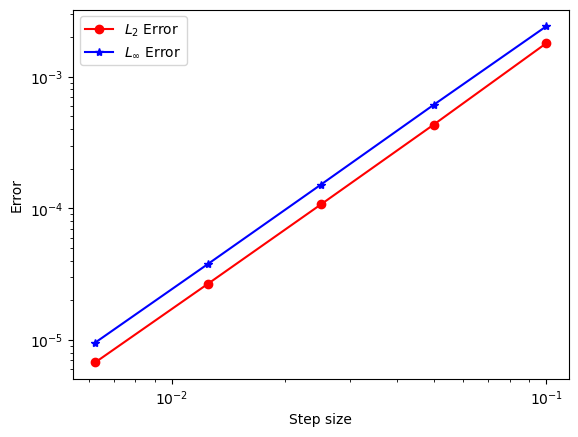

(np.float64(1.9974203736149418),
 array([0.1    , 0.05   , 0.025  , 0.0125 , 0.00625]),
 array([2.41595270e-03, 6.10685704e-04, 1.51283543e-04, 3.78376938e-05,
        9.56351938e-06]))

In [ ]:
# Spatial Convergence
def space_heat_wrapper(N):
    #Defining our step size
    dx = 1.0/N

    #Assigning parameters
    a = np.pi**-2
    T = 1
    alpha = 0
    beta = 1
    u_0 = lambda x: np.sin(2*np.pi*x) + x
    M = 1000000 #Maintianing a large temporal step count for minimal error interference
    f = None

    #Asigning our exact and numerical solution
    u_num, x, t = heat_eq(f, N, M, alpha, beta, u_0, a, T)
    u_exact = np.exp(-4*T) * np.sin(2*np.pi*x) + x

    #Finding Error
    L_inf_error = np.max(np.abs(u_num[:, -1] - u_exact))
    L2_error = np.sqrt(dx*np.sum((u_num[:, -1] - u_exact)**2))
    
    return dx, L2_error, L_inf_error

N_values = [10, 20, 40, 80, 160]

plot_convergence(space_heat_wrapper, N_values)


## Discussion

TODO:$\newline$
Verification of order of convergence $\newline$
Comparison of Error Norms $\newline$
Temporal vs Spatial Convergence $\newline$
Edge-Cases and Limitations $\newline$

## Summary
